In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from tqdm import tqdm

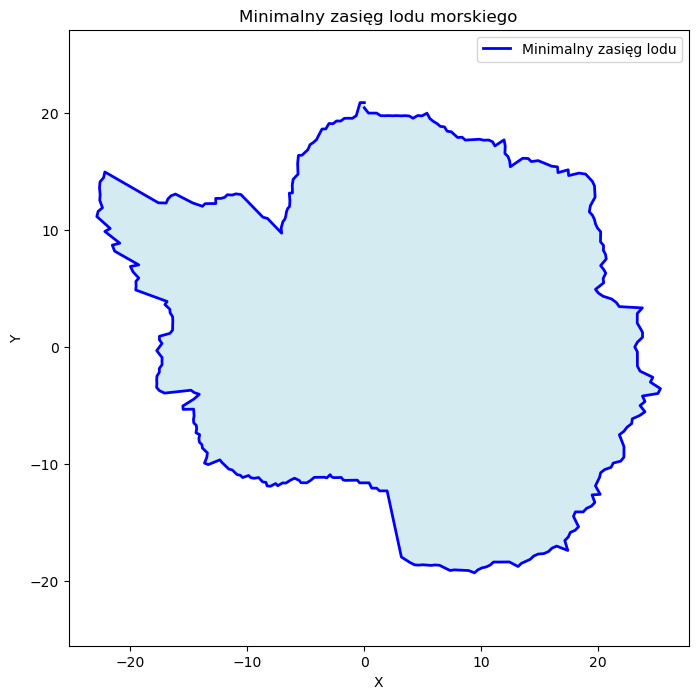

In [3]:
df = pd.read_csv('daily_ice_edge.csv')

ice_data = df.drop(columns=["Date"])
min_extent = ice_data.min(axis=0)
angles = np.array([int(col.split('_')[1][:-1]) for col in min_extent.index])

radii = 90 - np.abs(min_extent.values)
theta = np.deg2rad(angles)
x = radii * np.sin(theta)
y = radii * np.cos(theta)
 
plt.figure(figsize=(8,8))
plt.plot(x, y, color='blue', linewidth=2, label='Minimalny zasięg lodu')
plt.fill(x, y, color='lightblue', alpha=0.5)

plt.axhline(0, color='gray', lw=0)
plt.axvline(0, color='gray', lw=0)
 
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Minimalny zasięg lodu morskiego')
plt.legend()
plt.axis('equal')  
plt.show()

In [4]:
df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)
df = df.copy()

ice_columns = [col for col in df.columns if col.startswith("longitude_")]
angles = np.array([int(col.split('_')[1][:-1]) for col in ice_columns])
theta = np.deg2rad(angles)

real_data = []

for i, row in df.iterrows():
    r_real = 90 - np.abs(row[ice_columns].values)
    x_real = r_real * np.sin(theta)
    y_real = r_real * np.cos(theta)
    for angle, x, y in zip(angles, x_real, y_real):
        real_data.append({"Date": i.strftime('%Y-%m-%d'), "Angle": angle, "X": x, "Y": y})

real_df = pd.DataFrame(real_data)
real_df.to_csv("dane_rzeczywiste.csv", index=False)
print("Zapisano dane rzeczywiste do dane_rzeczywiste.csv")

Zapisano dane rzeczywiste do dane_rzeczywiste.csv


C:\Users\szymo\AppData\Local\Temp\ipykernel_17556\3516373086.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["days"] = (df.index - df.index.min()).days


Dopasowywanie modelu...


Krzywe dopasowania: 100%|████████████████████████████████████████████████████████████| 361/361 [01:09<00:00,  5.18it/s]


Obliczanie i zapisywanie danych modelowanych...


Klatki danych: 100%|███████████████████████████████████████████████████████████████| 9530/9530 [02:45<00:00, 57.52it/s]


Zapisano dane modelu do model_data.csv


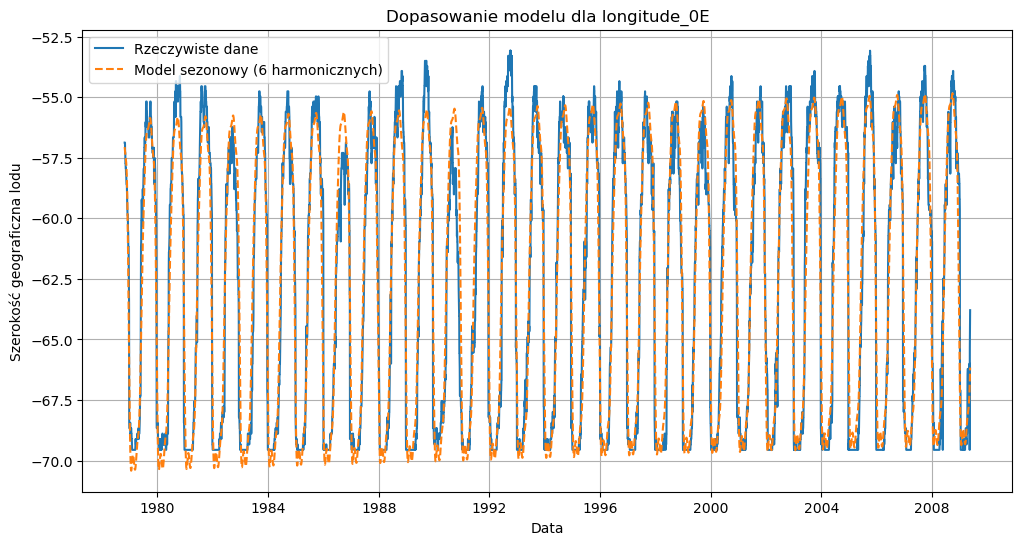

In [5]:
df[ice_columns] = df[ice_columns].interpolate(method="time")
df["days"] = (df.index - df.index.min()).days
time_vals = df["days"].values

def seasonal_model_extended(t, A1, phi1, A2, phi2, A3, phi3,
                            A4, phi4, A5, phi5, A6, phi6, B, C):
    T = 365.25
    return (A1 * np.cos(2 * np.pi / T * (t - phi1)) +
            A2 * np.cos(4 * np.pi / T * (t - phi2)) +
            A3 * np.cos(6 * np.pi / T * (t - phi3)) +
            A4 * np.cos(8 * np.pi / T * (t - phi4)) +
            A5 * np.cos(10 * np.pi / T * (t - phi5)) +
            A6 * np.cos(12 * np.pi / T * (t - phi6)) +
            B +
            C * t)

fitted_params = {}
print("Dopasowywanie modelu...")
for col in tqdm(ice_columns, desc="Krzywe dopasowania"):
    y_vals = df[col].values
    mask = ~np.isnan(y_vals)
    try:
        p0 = [10, 0, 5, 0, 2, 0, 1, 0, 0.5, 0, 0.2, 0, np.mean(y_vals[mask]), 0]
        params, _ = curve_fit(seasonal_model_extended, time_vals[mask], y_vals[mask], p0=p0, maxfev=20000)
        fitted_params[col] = params
    except RuntimeError:
        print(f"Nie udało się dopasować modelu dla {col}")
        fitted_params[col] = None

model_data = []
print("Obliczanie i zapisywanie danych modelowanych...")
for frame in tqdm(range(len(df)), desc="Klatki danych"):
    date = df.index[frame]
    t = df["days"].iloc[frame]
    for i, col in enumerate(ice_columns):
        params = fitted_params.get(col)
        if params is not None:
            (A1, phi1, A2, phi2, A3, phi3,
             A4, phi4, A5, phi5, A6, phi6, B, C) = params
            r = 90 - np.abs(seasonal_model_extended(t, A1, phi1, A2, phi2, A3, phi3, A4, phi4, A5, phi5, A6, phi6, B, C))
            x = r * np.sin(theta[i])
            y = r * np.cos(theta[i])
            model_data.append({"Date": date.strftime('%Y-%m-%d'),"Angle": angles[i],"X": x, "Y": y})
            
model_df = pd.DataFrame(model_data)
model_df.to_csv("model_data.csv", index=False)
print("Zapisano dane modelu do model_data.csv")

sample_col = ice_columns[0]
params = fitted_params.get(sample_col)

if params is not None:
    (A1, phi1, A2, phi2, A3, phi3,
     A4, phi4, A5, phi5, A6, phi6, B, C) = params
    model_vals = seasonal_model_extended(
        time_vals, A1, phi1, A2, phi2, A3, phi3,
        A4, phi4, A5, phi5, A6, phi6, B, C)
else:
    print(f"Nie udało się dopasować modelu dla {sample_col}")

Tworzenie animacji:   0%|                                                         | 1/1906 [00:00<05:21,  5.92klatka/s]

Generowanie animacji GIF...


Tworzenie animacji: 100%|██████████████████████████████████████████████████████| 1906/1906 [11:27<00:00,  2.77klatka/s]


Animacja zapisana jako lod_z_csv.gif


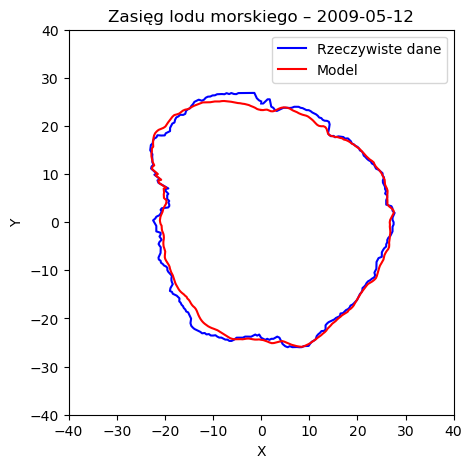

In [6]:
real_df = pd.read_csv("dane_rzeczywiste.csv")
model_df = pd.read_csv("model_data.csv")
real_df["Date"] = pd.to_datetime(real_df["Date"])
model_df["Date"] = pd.to_datetime(model_df["Date"])

unique_dates = sorted(real_df["Date"].unique())
frames = list(range(0, len(unique_dates), 5))

fig, ax = plt.subplots(figsize=(5, 5))
real_line, = ax.plot([], [], color='blue', label='Rzeczywiste dane')
model_line, = ax.plot([], [], color='red', label='Model')
ax.set_xlim(-40, 40)
ax.set_ylim(-40, 40)
ax.set_aspect('equal')
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.legend()

def init():
    real_line.set_data([], [])
    model_line.set_data([], [])
    return real_line, model_line

progress_bar = tqdm(total=len(frames), desc="Tworzenie animacji", unit="klatka")

def update(frame):
    date = unique_dates[frame]
    real = real_df[real_df["Date"] == date]
    model = model_df[model_df["Date"] == date]

    real_line.set_data(real["X"], real["Y"])
    model_line.set_data(model["X"], model["Y"])
    ax.set_title(f"Zasięg lodu morskiego – {date.strftime('%Y-%m-%d')}")
    progress_bar.update(1)
    return real_line, model_line

print("Generowanie animacji GIF...")
ani = FuncAnimation(fig, update, frames=frames, init_func=init, blit=True, interval=100)
ani.save("lod_z_csv.gif", writer=PillowWriter(fps=10))
progress_bar.close()
print("Animacja zapisana jako lod_z_csv.gif")

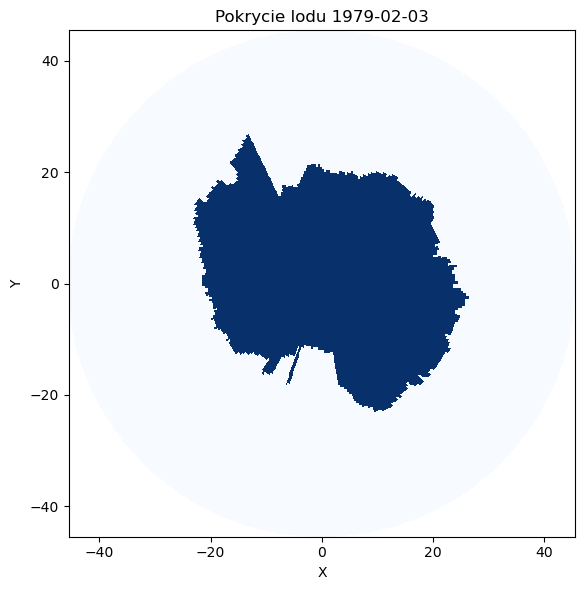

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Wczytanie danych
df = pd.read_csv("daily_ice_edge.csv")
df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)

# Siatka
lat_grid = np.arange(-90, -44.0, 0.5)
lon_grid = np.arange(0, 361, 1)

# Wczytanie danych z pierwszego dnia
date = df.index[50]
ice_grid = np.zeros((len(lat_grid), len(lon_grid)), dtype=np.uint8)

for lon_idx, lon in enumerate(lon_grid):
    col_name = f"longitude_{lon}E"
    if col_name in df.columns:
        ice_edge_lat = df.loc[date, col_name]
        if isinstance(ice_edge_lat, pd.Series):
            ice_edge_lat = ice_edge_lat.iloc[0]
        if pd.notnull(ice_edge_lat):
            mask = lat_grid <= ice_edge_lat
            ice_grid[mask, lon_idx] = 1
            



theta = np.deg2rad(lon_grid)
r = 90 - np.abs(lat_grid)
Theta, R = np.meshgrid(theta, r)
ice_grid = ice_grid[:len(r)-1, :len(theta)-1]

Y = R * np.cos(Theta)
X = R * np.sin(Theta)

fig, ax = plt.subplots(figsize=(6, 6))
pcm = ax.pcolormesh(X, Y, ice_grid, cmap='Blues')
ax.set_aspect('equal')
ax.set_title(f"Pokrycie lodu {date.strftime('%Y-%m-%d')}")
ax.set_xlabel("X")
ax.set_ylabel("Y")

plt.tight_layout()
plt.show()